# 07 · The Certificate `Δ̂ ± ε` & Calibration

Three interchangeable certificates: split-**conformal**, **empirical-Bernstein** (= ELARA T5),
and an **anytime-valid e-value** (Thm 3b). All control the false-adapt rate at level α:
`ADAPT iff Δ̂−ε>0`, `FREEZE iff Δ̂+ε<0`, else `ABSTAIN`.


In [1]:
import os, json, glob, numpy as np
REPO=os.path.abspath(os.getcwd())
while REPO!='/' and not os.path.exists(os.path.join(REPO,'scripts','rebuild_kbound.sh')): REPO=os.path.dirname(REPO)
RES=os.path.join(REPO,'experiments','kbound','results'); FIG=os.path.join(REPO,'docs','research','kbound','figures')
ARCH=os.path.join(REPO,'experiments','elara_u','score_archive'); ELA=os.path.join(REPO,'experiments','elara_u')
from IPython.display import Image, display
def jload(p):
    fp=p if os.path.isabs(p) else os.path.join(RES,p)
    return json.load(open(fp)) if os.path.exists(fp) else {}
def fig(fn,w=720):
    p=os.path.join(FIG,fn)
    if os.path.exists(p): display(Image(filename=p,width=w))
print('repo:',REPO)

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8


### α–coverage tradeoff (tunable safety knob)
Lower α ⇒ tighter certificate ⇒ fewer commits but lower false-adapt; the empirical false-adapt
tracks the nominal α — theory and experiment agree.


alpha : coverage : false_adapt
  0.01   0.11      0.000
  0.05   0.26      0.074
  0.1    0.35      0.065
  0.2    0.49      0.072


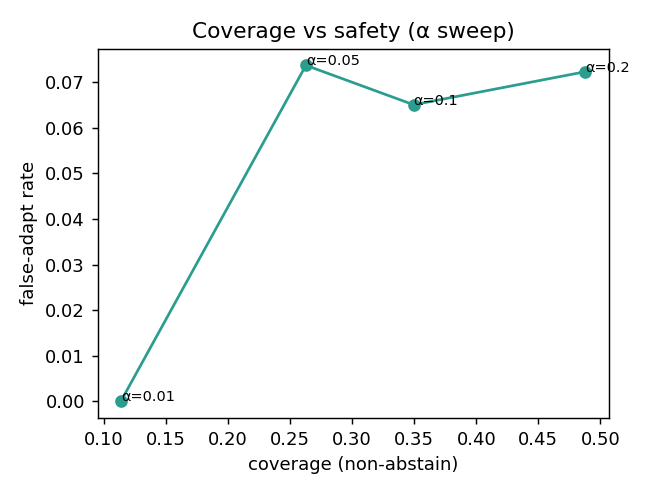

In [2]:
a=jload('ablations.json')
print('alpha : coverage : false_adapt')
for k,v in a.get('alpha_sweep',{}).items(): print('  %-5s  %.2f      %.3f'%(k,v.get('coverage',float('nan')),v.get('false_adapt',float('nan'))))
fig('fig_alpha_coverage.png')

### Anytime-valid (testing-by-betting) certificate
Valid at *any* stopping time via Ville's inequality — no multiplicity correction for repeated looks.


In [3]:
tv=os.path.join(REPO,'experiments','kbound','theory_validation','val_thm3_evalue_results.json')
d=json.load(open(tv)) if os.path.exists(tv) else {}
print('e-value certificate validation:', {k:d[k] for k in list(d)[:8]} if d else 'run val_thm3_evalue.py')

e-value certificate validation: {'config': {'alpha': 0.1, 'horizon': 2000, 'n_runs': 20000, 'seed': 0, 'bet_cap_frac': 0.5, 'out': '/sessions/funny-inspiring-tesla/mnt/uav/AutoML_Flagship_V8/experiments/kbound/theory_validation/val_thm3_evalue_results.json'}, 'results': {'false_adapt_h0': [{'stream': 'twopoint', 'delta': -0.2, 'alpha': 0.1, 'horizon': 2000, 'n_runs': 20000, 'cross_rate': 0.00505, 'n_crossed': 101, 'mean_stop_time': 12.178217821782178, 'median_stop_time': 10.0, 'p90_stop_time': 18.0, 'mean_log_wealth_final': -0.6659697074788293}, {'stream': 'twopoint', 'delta': -0.05, 'alpha': 0.1, 'horizon': 2000, 'n_runs': 20000, 'cross_rate': 0.0268, 'n_crossed': 536, 'mean_stop_time': 26.759328358208954, 'median_stop_time': 14.0, 'p90_stop_time': 54.5, 'mean_log_wealth_final': -1.304758049895683}, {'stream': 'twopoint', 'delta': 0.0, 'alpha': 0.1, 'horizon': 2000, 'n_runs': 20000, 'cross_rate': 0.0626, 'n_crossed': 1252, 'mean_stop_time': 159.69488817891374, 'median_stop_time': 24.5